In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from plot import (
    setup_style,
    AXES, AXIS_COLOR, AXIS_LABEL,
    PRIMARY_COLOR, SECONDARY_COLOR,
)

setup_style()

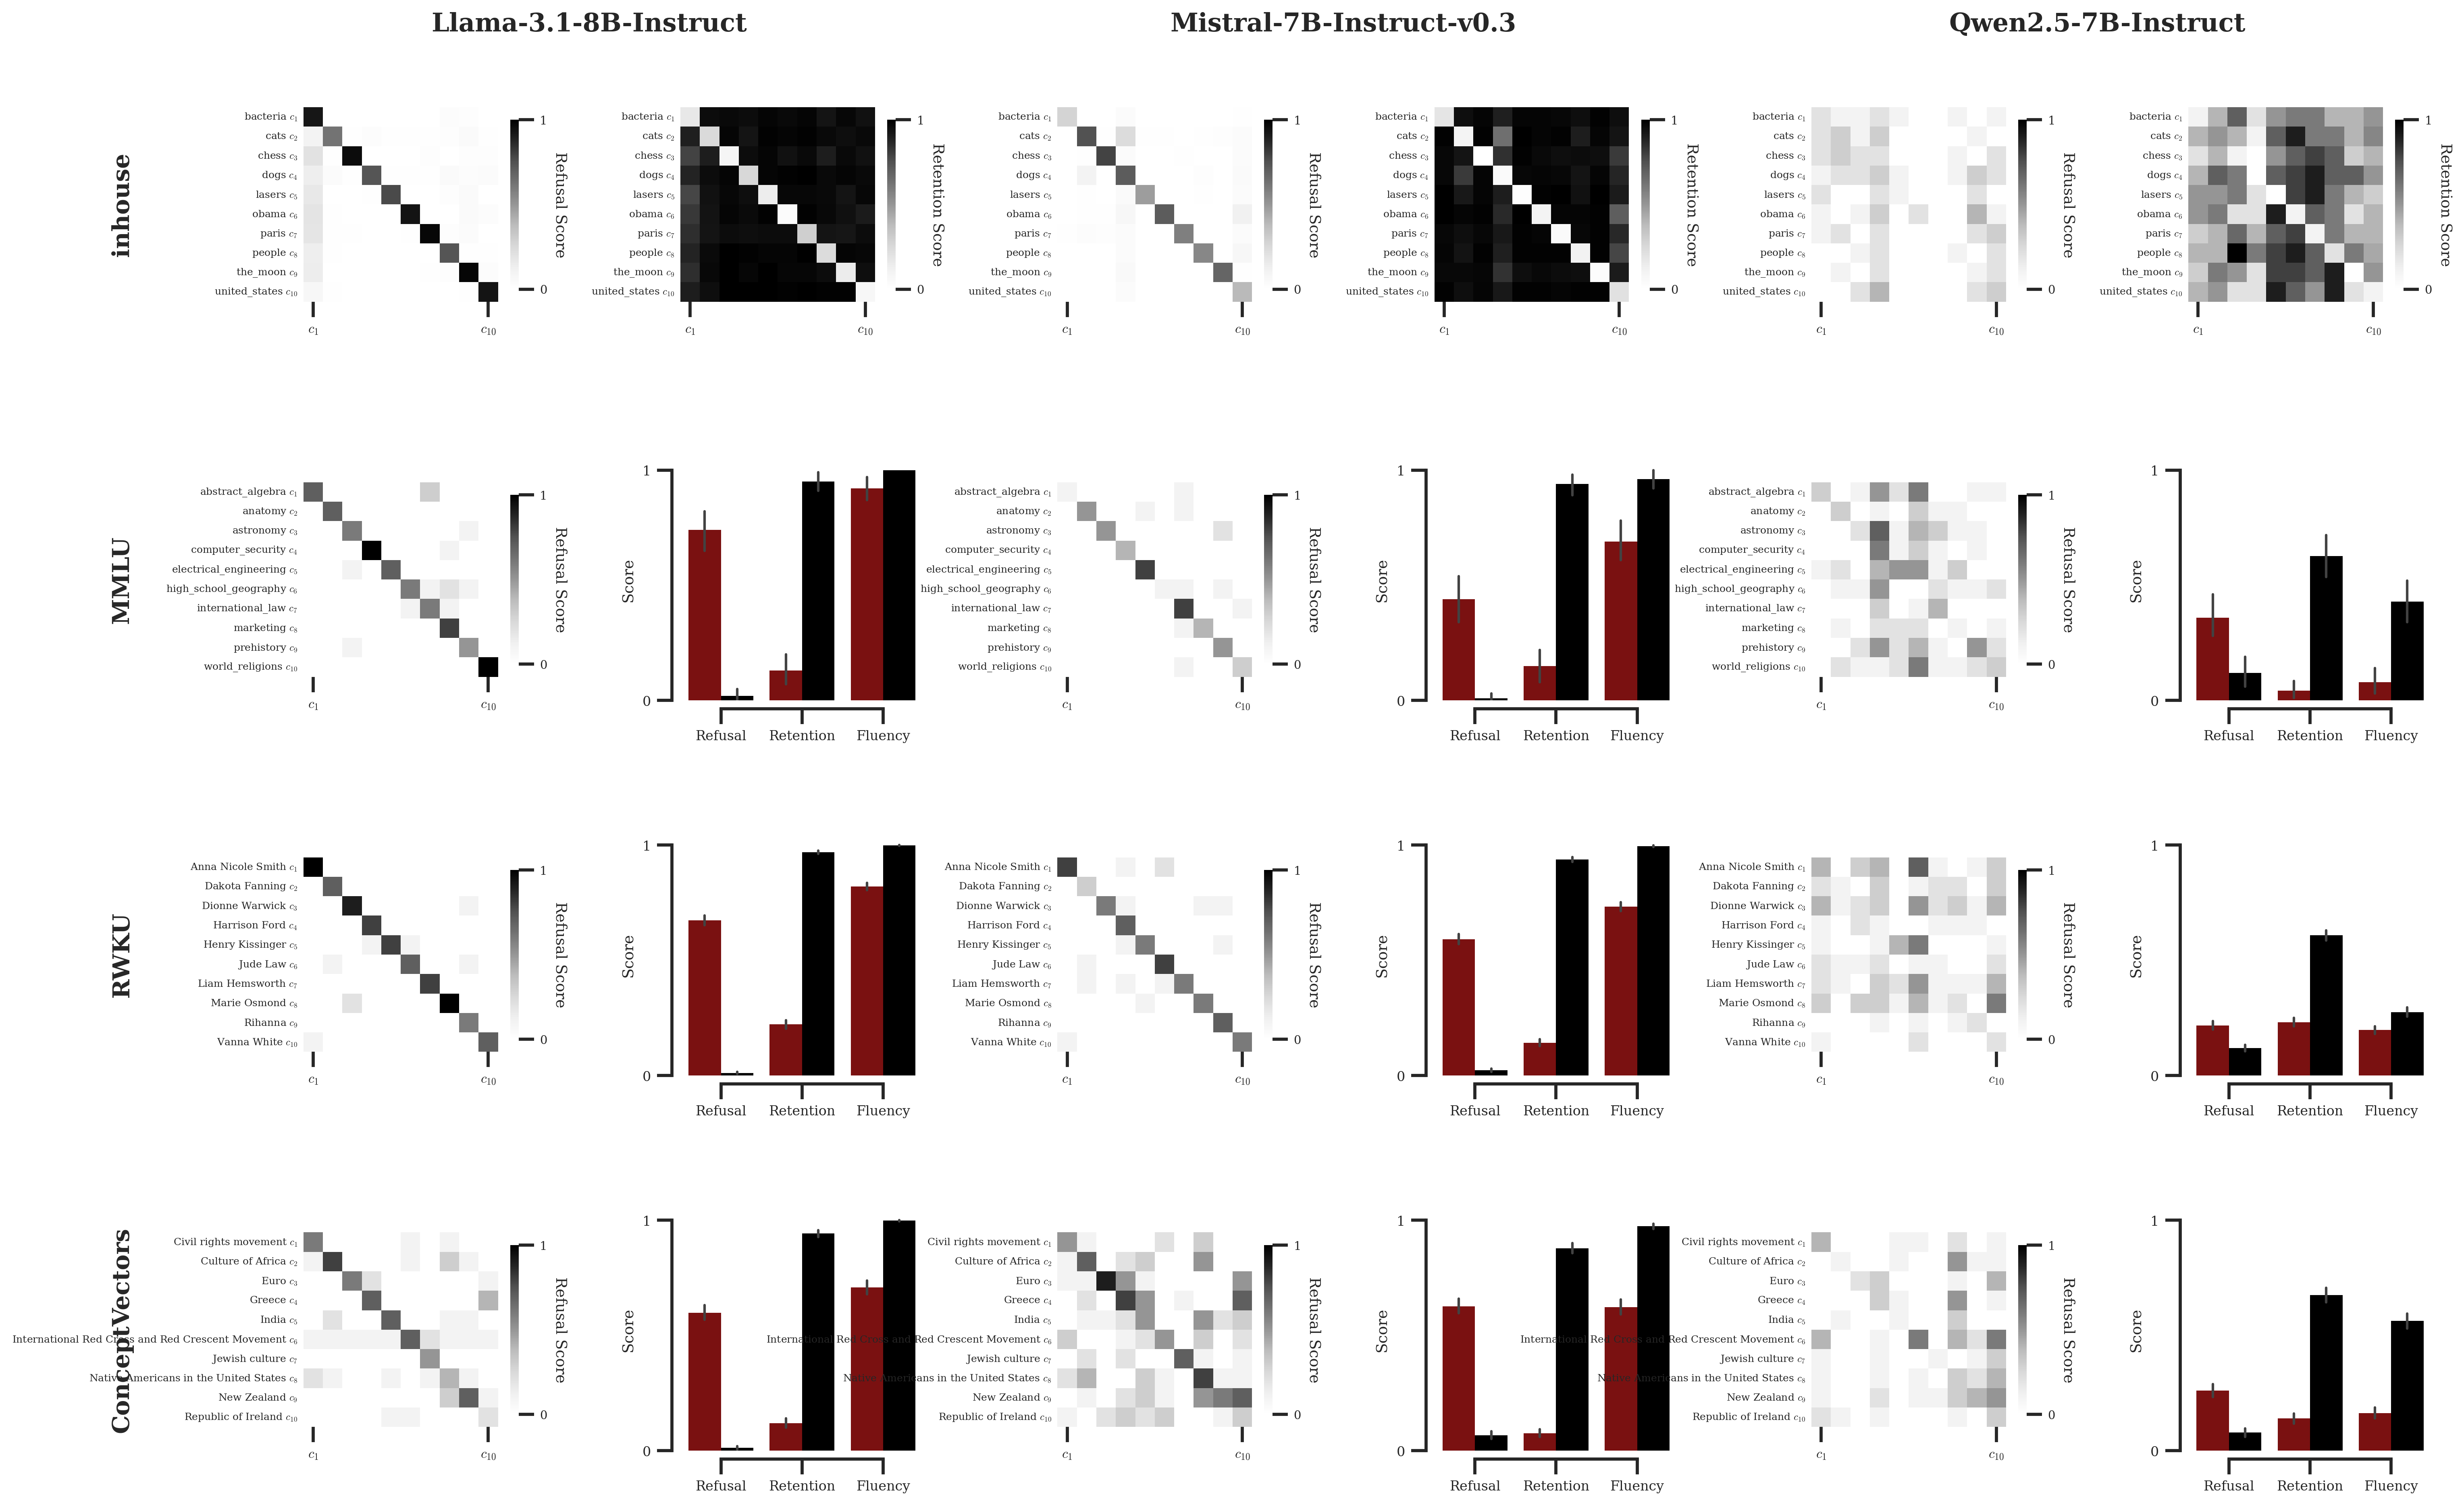

In [2]:
import ast
from pathlib import Path

STORE = Path("../store")

MODELS = [
    ("Llama-3.1-8B-Instruct",     "llama8b"),
    ("Mistral-7B-Instruct-v0.3",  "mistral7b"),
    ("Qwen2.5-7B-Instruct",       "qwen7b"),
]
ROWS = [
    ("inhouse",        "inhouse"),
    ("MMLU",           "mmlu"),
    ("RWKU",           "rwku"),
    ("ConceptVectors", "conceptvectors"),
]

# hardcoded: runs that crashed and won't produce data on the current pass
ERRORED = {
    ("mistral7b", "conceptvectors"),
    ("qwen7b",    "mmlu"),
    ("qwen7b",    "conceptvectors"),
}


def status_for(file_path, model_key, row_key, required_cols=()):
    if not file_path.exists():
        return "error" if (model_key, row_key) in ERRORED else "calculating"
    if required_cols:
        cols = pd.read_csv(file_path, nrows=0).columns
        if not all(c in cols for c in required_cols):
            return "calculating"
    return None


def _derive_intervention_layers(df):
    raw = df["source_layer"].iloc[0]
    return list(ast.literal_eval(raw)) if isinstance(raw, str) else list(raw)


def _derive_scale(df):
    nonzero = sorted(s for s in df.loc[df["label"] == "intervention", "scale"].unique() if s != 0)
    return float(nonzero[0])


def _heatmap_pivot(judged_csv, metric):
    df = pd.read_csv(judged_csv)
    layers = str(_derive_intervention_layers(df))
    scale = _derive_scale(df)
    plot_df = df[
        (df["label"] == "intervention")
        & (df["scale"] == scale)
        & (df["source_layer"].astype(str) == layers)
        & (df["target_layer"].astype(str) == layers)
    ]
    concepts = list(df["concept"].unique())
    scores = (
        plot_df.pivot_table(index="concept", columns="target", values=metric, aggfunc="mean")
        .reindex(index=concepts, columns=concepts)
    )
    return scores, concepts


def draw_heatmap(ax, judged_csv, metric, cbar_label):
    scores, concepts = _heatmap_pivot(judged_csv, metric)
    n = scores.shape[0]
    label_each = n <= 12
    yticklabels = [f"{c} $c_{{{i+1}}}$" for i, c in enumerate(concepts)] if label_each else False
    sns.heatmap(
        scores.fillna(0), ax=ax, cmap="Greys", square=True, vmin=0, vmax=1,
        xticklabels=False, yticklabels=yticklabels,
        cbar_kws={"shrink": 0.7, "ticks": [0, 1]},
    )
    ax.set_xticks([0.5, n - 0.5], labels=["$c_1$", f"$c_{{{n}}}$"])
    if not label_each:
        ax.set_yticks([0.5, n - 0.5], labels=["$c_1$", f"$c_{{{n}}}$"])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=6, length=0)
    ax.tick_params(axis="x", labelsize=8, rotation=0)
    cbar = ax.collections[0].colorbar
    cbar.ax.set_ylabel(cbar_label, rotation=270, labelpad=12, fontsize=9)
    cbar.ax.tick_params(labelsize=7)


def draw_bars(ax, judged_csv):
    df = pd.read_csv(judged_csv)
    if "label" in df:
        df = df[df["label"] == "intervention"]
    df = df.assign(kind=np.where(df["concept"] == df["target"], "Target", "Untargeted"))
    score_cols = [f"judge_{a}" for a in AXES if f"judge_{a}" in df.columns]
    long_df = df[["kind"] + score_cols].melt(id_vars="kind", var_name="axis", value_name="score")
    long_df["axis"] = long_df["axis"].str.replace("judge_", "").str.title()
    sns.barplot(
        data=long_df, x="axis", y="score", hue="kind", ax=ax,
        order=[AXIS_LABEL[a] for a in AXES if f"judge_{a}" in df.columns],
        hue_order=["Target", "Untargeted"],
        palette={"Target": PRIMARY_COLOR, "Untargeted": SECONDARY_COLOR},
        errorbar=("ci", 95),
    )
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    ax.set_xlabel("")
    ax.set_ylabel("Score", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0, 1])
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    sns.despine(ax=ax, trim=True, offset=5)


def draw_status_box(ax, status):
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(True)
        s.set_color("0.75")
        s.set_linewidth(1)
    ax.text(0.5, 0.5, status, transform=ax.transAxes,
            ha="center", va="center", fontsize=13, color="0.45", style="italic")


BARS_COLS = ("judge_refusal", "judge_retention", "judge_fluency")

fig, axes = plt.subplots(4, 6, figsize=(20, 13))
fig.subplots_adjust(left=0.10, right=0.98, top=0.92, bottom=0.05,
                    wspace=0.55, hspace=0.55)

for r, (_, row_key) in enumerate(ROWS):
    for mi, (_, model_key) in enumerate(MODELS):
        store_dir = STORE / f"{model_key}_{row_key}"
        conf_csv = store_dir / "confusion_judged.csv"
        bars_csv = store_dir / "bars_judged.csv"
        ax_left  = axes[r, mi*2]
        ax_right = axes[r, mi*2 + 1]

        # left slot: refusal heatmap from confusion_judged
        s = status_for(conf_csv, model_key, row_key, ("judge_refusal",))
        if s is None:
            draw_heatmap(ax_left, conf_csv, "judge_refusal", "Refusal Score")
        else:
            draw_status_box(ax_left, s)

        # right slot: retention heatmap (inhouse) or bars chart (other rows)
        if row_key == "inhouse":
            s = status_for(conf_csv, model_key, row_key, ("judge_retention",))
            if s is None:
                draw_heatmap(ax_right, conf_csv, "judge_retention", "Retention Score")
            else:
                draw_status_box(ax_right, s)
        else:
            s = status_for(bars_csv, model_key, row_key, BARS_COLS)
            if s is None:
                draw_bars(ax_right, bars_csv)
            else:
                draw_status_box(ax_right, s)

fig.canvas.draw()

for mi, (model_label, _) in enumerate(MODELS):
    bl = axes[0, mi*2].get_position()
    br = axes[0, mi*2 + 1].get_position()
    fig.text((bl.x0 + br.x1) / 2, 0.95, model_label,
             ha="center", va="bottom", fontsize=15, weight="bold")

for r, (row_label, _) in enumerate(ROWS):
    bbox = axes[r, 0].get_position()
    fig.text(0.025, (bbox.y0 + bbox.y1) / 2, row_label,
             ha="center", va="center", rotation=90, fontsize=14, weight="bold")

plt.show()

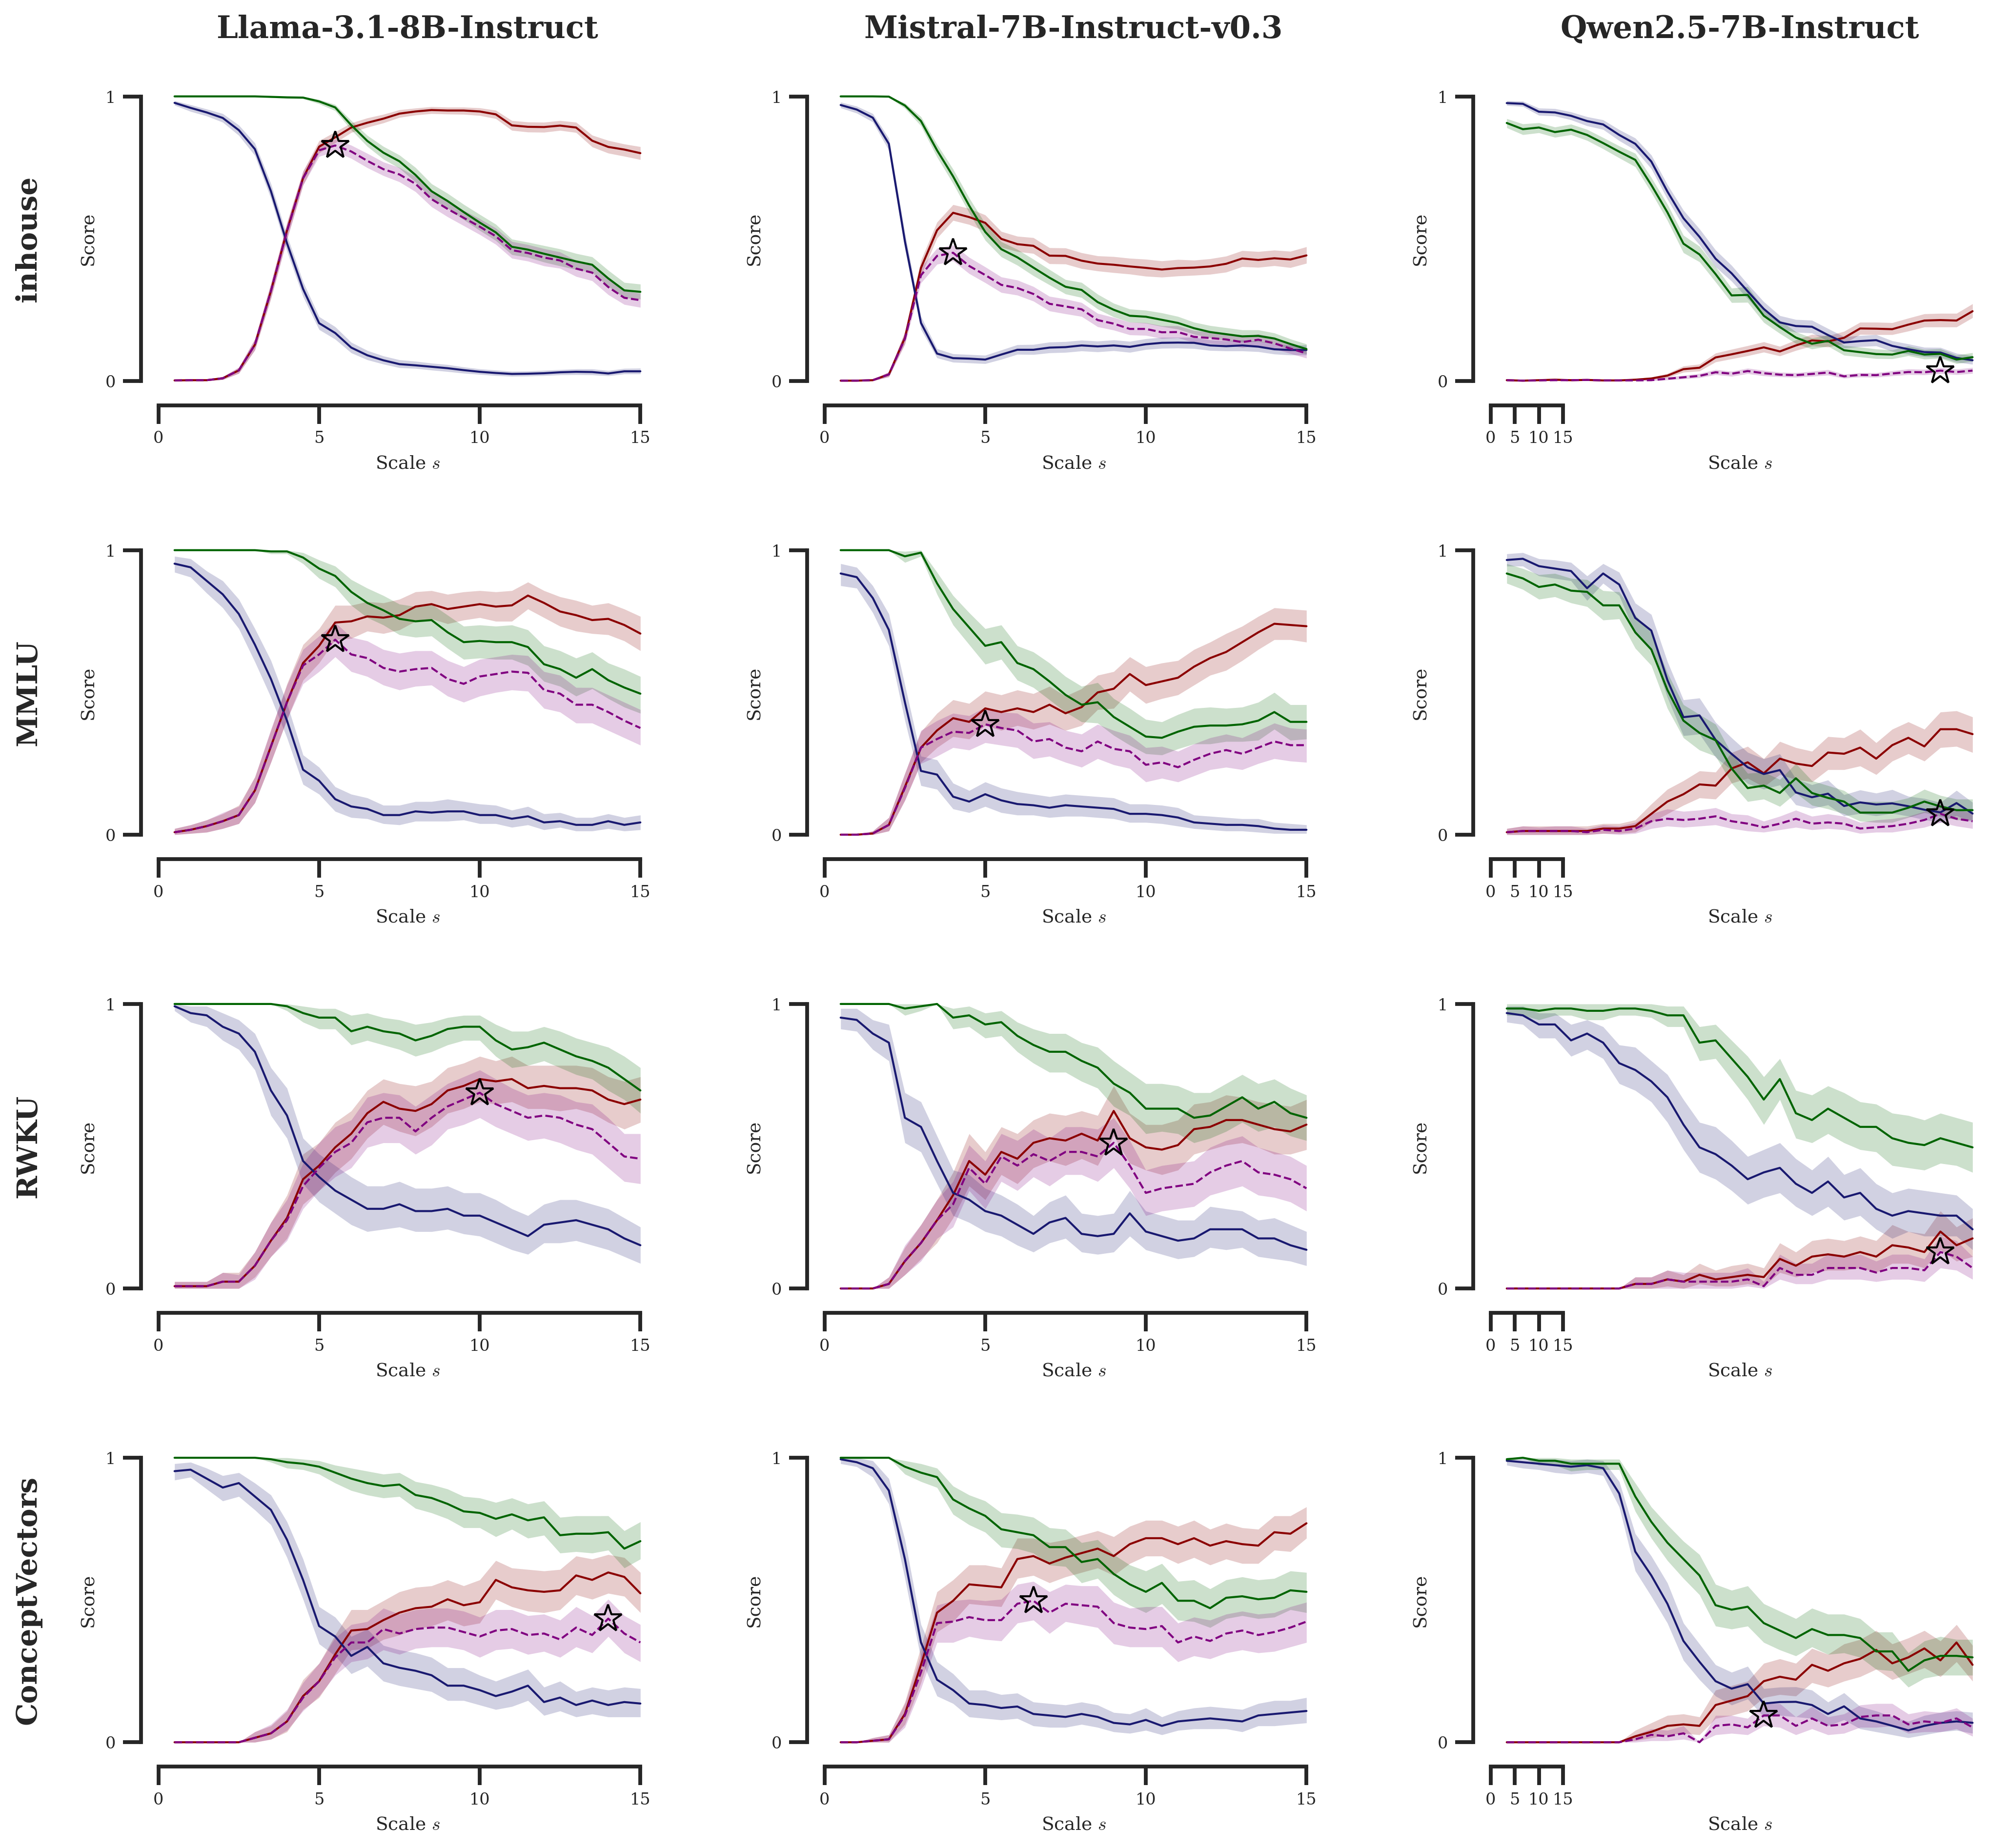

In [3]:
HARMONIC_COLOR = "purple"
EPS = 1e-9
CALIB_COLS = ("judge_refusal", "judge_retention", "judge_fluency")


def draw_calibration(ax, calibration_csv):
    df = pd.read_csv(calibration_csv)
    if "label" in df:
        df = df[df["label"] == "intervention"]
    df = df.assign(
        judge_harmonic=2 * df["judge_refusal"] * df["judge_fluency"]
                       / (df["judge_refusal"] + df["judge_fluency"] + EPS)
    )

    for axis in AXES:
        col = f"judge_{axis}"
        if col not in df.columns:
            continue
        sns.lineplot(
            data=df, x="scale", y=col, ax=ax,
            color=AXIS_COLOR[axis], label=AXIS_LABEL[axis],
            estimator="mean", errorbar=("ci", 95),
        )

    sns.lineplot(
        data=df, x="scale", y="judge_harmonic", ax=ax,
        color=HARMONIC_COLOR, label="Harmonic (R, F)",
        estimator="mean", errorbar=("ci", 95), linestyle="--",
    )

    means = df.groupby("scale", as_index=False)["judge_harmonic"].mean()
    peak = means.sort_values(["judge_harmonic", "scale"], ascending=[False, True]).iloc[0]
    ax.plot(peak["scale"], peak["judge_harmonic"],
            marker="*", color=SECONDARY_COLOR,
            markersize=14, fillstyle="none", linestyle="None")

    ax.set_xlabel("Scale $s$", fontsize=9)
    ax.set_ylabel("Score", fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([0, 1])
    ax.set_xticks([0, 5, 10, 15])
    ax.tick_params(labelsize=8)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    sns.despine(ax=ax, trim=True, offset=5)


fig, axes = plt.subplots(4, 3, figsize=(14, 13))
fig.subplots_adjust(left=0.08, right=0.98, top=0.93, bottom=0.05,
                    wspace=0.30, hspace=0.45)

for r, (_, row_key) in enumerate(ROWS):
    for mi, (_, model_key) in enumerate(MODELS):
        cal_csv = STORE / f"{model_key}_{row_key}" / "calibration_judged.csv"
        ax = axes[r, mi]
        s = status_for(cal_csv, model_key, row_key, CALIB_COLS)
        if s is None:
            draw_calibration(ax, cal_csv)
        else:
            draw_status_box(ax, s)

fig.canvas.draw()

for mi, (model_label, _) in enumerate(MODELS):
    bbox = axes[0, mi].get_position()
    fig.text((bbox.x0 + bbox.x1) / 2, 0.95, model_label,
             ha="center", va="bottom", fontsize=15, weight="bold")

for r, (row_label, _) in enumerate(ROWS):
    bbox = axes[r, 0].get_position()
    fig.text(0.02, (bbox.y0 + bbox.y1) / 2, row_label,
             ha="center", va="center", rotation=90, fontsize=14, weight="bold")

plt.show()